In [1]:
import pandas as pd
import numpy as np

# For basic visualization (later)
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load dataset
df = pd.read_csv("../data/Combined Data.csv")

# View first 5 rows
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.shape

(53043, 3)

In [4]:
df.columns

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

In [5]:
df.dtypes

Unnamed: 0     int64
statement     object
status        object
dtype: object

In [6]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [7]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [8]:
# Drop unwanted index column
df = df.drop(columns=['Unnamed: 0'])

In [9]:
# Drop rows with missing text
df = df.dropna(subset=['statement'])

In [10]:
df.isnull().sum()

statement    0
status       0
dtype: int64

In [11]:
df.shape

(52681, 2)

In [12]:
df['status'].value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

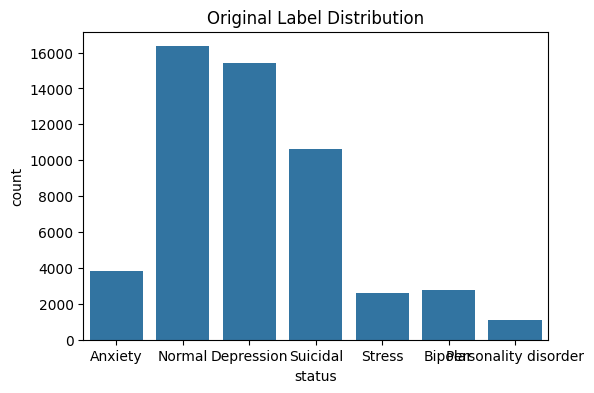

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df)
plt.title("Original Label Distribution")
plt.show()

In [14]:
df['text_length'] = df['statement'].apply(lambda x: len(x.split()))

df['text_length'].describe()

count    52681.000000
mean       113.158729
std        163.735305
min          1.000000
25%         15.000000
50%         62.000000
75%        148.000000
max       6300.000000
Name: text_length, dtype: float64

In [15]:
# Create anxiety_level column using mapping
label_mapping = {
    'Normal': 0,
    'Stress': 1,
    'Anxiety': 1,
    'Depression': 2,
    'Suicidal': 2,
    'Bipolar': 2,
    'Personality disorder': 2
}

df['anxiety_level'] = df['status'].map(label_mapping)

# Check if any labels were not mapped
df['anxiety_level'].isnull().sum()

np.int64(0)

In [16]:
df['anxiety_level'].value_counts()

anxiety_level
2    29910
0    16343
1     6428
Name: count, dtype: int64

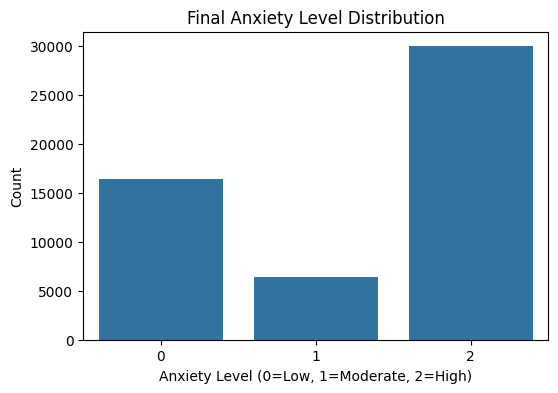

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='anxiety_level', data=df)
plt.title("Final Anxiety Level Distribution")
plt.xlabel("Anxiety Level (0=Low, 1=Moderate, 2=High)")
plt.ylabel("Count")
plt.show()

In [18]:
final_df = df[['statement', 'anxiety_level']].copy()

final_df.head()

,statement,anxiety_level
0,oh my gosh,1
1,"trouble sleeping, confused mind, restless hear...",1
2,"All wrong, back off dear, forward doubt. Stay ...",1
3,I've shifted my focus to something else but I'...,1
4,"I'm restless and restless, it's been a month n...",1


In [19]:
final_df = final_df.rename(columns={'statement': 'text'})

final_df.head()

,text,anxiety_level
0,oh my gosh,1
1,"trouble sleeping, confused mind, restless hear...",1
2,"All wrong, back off dear, forward doubt. Stay ...",1
3,I've shifted my focus to something else but I'...,1
4,"I'm restless and restless, it's been a month n...",1


In [20]:
final_df.to_csv("../data/final_anxiety_dataset.csv", index=False)

In [21]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import prepare_dataloaders

train_enc, val_enc, y_train, y_val = prepare_dataloaders(
    "../data/final_anxiety_dataset.csv"
)

print(train_enc['input_ids'].shape)
print(y_train.shape)

c:\Users\techl\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\techl\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\techl\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an adminis

torch.Size([42144, 128])
torch.Size([42144])
